# Tellus magnetic grid — quick look

Sampling the airborne magnetic anomaly field along a flight path.
Run `python scripts/fetch_tellus.py` first if the grid isn't downloaded yet.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt

from tellus import MagneticGrid, products
from tellus.sample import straight_track

## Load the grid

Reads the GeoTIFF into memory once. Sampling after this is cheap.

In [2]:
grid = MagneticGrid('a7_tmi')
grid

<MagneticGrid 'Block A7 total magnetic intensity anomaly (microlevelled)' 1691x2246 cells, nT>

In [3]:
rows, cols = grid.shape
min_lon, min_lat, max_lon, max_lat = grid.bounds_wgs84

print('size      ', cols, 'x', rows, 'cells at', grid.resolution[0], 'm')
print('units     ', grid.units)
print('latitude  ', round(min_lat, 3), 'to', round(max_lat, 3))
print('longitude ', round(min_lon, 3), 'to', round(max_lon, 3))

size       1691 x 2246 cells at 50.0 m
units      nT
latitude   52.079 to 53.103
longitude  -7.226 to -5.946


## One point

Give it a latitude and longitude, get back the anomaly in nT.

In [4]:
grid.sample(52.45, -6.40)

74.53034747669942

Anywhere outside the survey returns `NaN`, never 0 — a zero would look like a real reading.

In [5]:
print('Dublin (outside this block):', grid.sample(53.35, -6.26))
print('mid-Atlantic:              ', grid.sample(52.5, -20.0))

Dublin (outside this block): nan
mid-Atlantic:               nan


## A flight path

`A7_DEMO_TRACK` is a 17 km line chosen to cross the strongest feature in this block.

In [6]:
start, end = products.A7_DEMO_TRACK
lats, lons = straight_track(start, end, n=400)
values = grid.sample_track(lats, lons)

print('points  ', len(values))
print('range   ', round(np.nanmin(values)), 'to', round(np.nanmax(values)), 'nT')
print('swing   ', round(np.nanmax(values) - np.nanmin(values)), 'nT')

points   400
range    -115 to 238 nT
swing    353 nT


Converting the track to metres gives an x-axis in kilometres rather than point number.

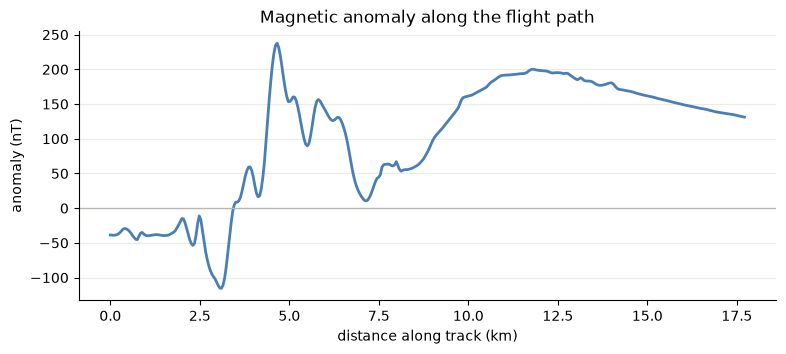

In [7]:
from pyproj import Transformer

to_itm = Transformer.from_crs('EPSG:4326', grid.crs, always_xy=True)
x, y = to_itm.transform(lons, lats)
distance_km = np.hypot(x - x[0], y - y[0]) / 1000

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(distance_km, values, color='#4a7fb5', linewidth=2)
ax.axhline(0, color='#b8b8b0', linewidth=1)
ax.set_xlabel('distance along track (km)')
ax.set_ylabel(f'anomaly ({grid.units})')
ax.set_title('Magnetic anomaly along the flight path')
ax.grid(axis='y', color='#ececE6')
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.show()

## Where that track sits on the grid

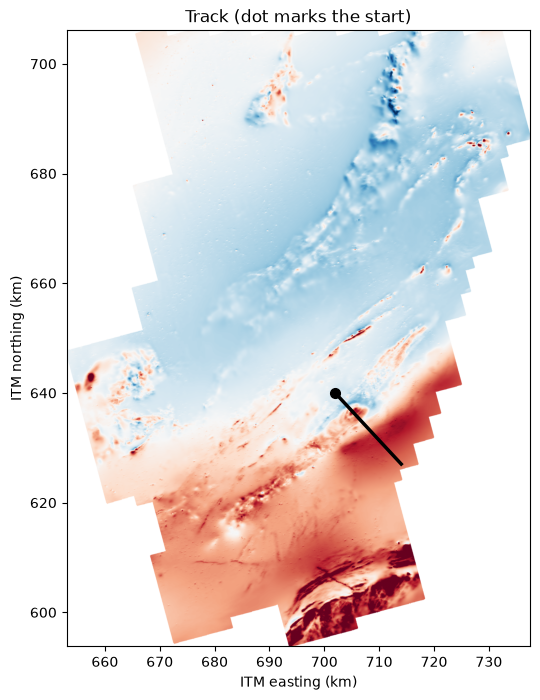

In [8]:
limit = np.nanpercentile(np.abs(grid.values), 99)
left, bottom, right, top = grid.bounds

fig, ax = plt.subplots(figsize=(7, 8))
ax.imshow(grid.values, origin='upper', cmap='RdBu_r', vmin=-limit, vmax=limit,
          extent=(left/1000, right/1000, bottom/1000, top/1000))
ax.plot(x/1000, y/1000, color='black', linewidth=2.5)
ax.plot(x[0]/1000, y[0]/1000, 'o', color='black', markersize=7)
ax.set_xlabel('ITM easting (km)')
ax.set_ylabel('ITM northing (km)')
ax.set_title('Track (dot marks the start)')
plt.show()

## Cutting out a smaller area

`subset` trims the grid to one region. It saves memory, and gives identical values.

In [9]:
bbox = (lons.min(), lats.min(), lons.max(), lats.max())
small = grid.subset(bbox)

print('full  ', grid.shape, f'{grid.values.nbytes/1e6:.0f} MB')
print('subset', small.shape, f'{small.values.nbytes/1e6:.1f} MB')
print('same values:', np.allclose(small.sample_track(lats, lons), values))

full   (2246, 1691) 30 MB
subset (311, 282) 0.7 MB
same values: True


It is not faster, though. Most of the time goes on converting lat/lon to the
grid's coordinate system, which costs the same either way.

In [10]:
big_lats, big_lons = straight_track(start, end, n=500_000)

%timeit grid.sample_track(big_lats, big_lons)
%timeit small.sample_track(big_lats, big_lons)

46.2 ms ± 3.71 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
44.9 ms ± 1.36 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Checks

The same assertions `pytest` runs, for a quick confirmation nothing has drifted.

In [11]:
import subprocess

result = subprocess.run([sys.executable, '-m', 'pytest', '-q'],
                        cwd='..', capture_output=True, text=True)
print(result.stdout[-2000:])

........                                                                 [100%]
8 passed in 0.21s

